# CRISP-DM: Proyecto Horse Colic

Este cuaderno de Google Colab contiene el desarrollo de las fases 1 a 3 de la metodología CRISP-DM aplicada al conjunto de datos *Horse Colic*.

## Paso 0: Carga de Datos y Configuración Inicial
A continuación, importaremos las librerías necesarias y cargaremos los conjuntos de datos de entrenamiento (`horse-colic.data`) y prueba (`horse-colic.test`). Se reemplazarán los valores `?` por nulos computacionales (`NaN`) y se asignarán los nombres a cada columna de acuerdo al diccionario de datos (`horse-colic.names`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Definición de nombres de columnas (28 atributos en total)
column_names = [
    'surgery', 'age', 'hospital_number', 'rectal_temp', 'pulse', 
    'respiratory_rate', 'temp_of_extremities', 'peripheral_pulse', 
    'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis', 
    'abdominal_distension', 'nasogastric_tube', 'nasogastric_reflux', 
    'nasogastric_reflux_ph', 'rectal_exam_feces', 'abdomen', 
    'packed_cell_volume', 'total_protein', 'abdominocentesis_appearance', 
    'abdomcentesis_total_protein', 'outcome', 'surgical_lesion', 
    'lesion_type_1', 'lesion_type_2', 'lesion_type_3', 'cp_data'
]

# Carga de datos de entrenamiento y prueba
# El dataset está separado por espacios y los nulos se representaron con '?'
df_train = pd.read_csv('horse-colic.data', sep=r'\s+', header=None, names=column_names, na_values='?')
df_test = pd.read_csv('horse-colic.test', sep=r'\s+', header=None, names=column_names, na_values='?')

print(f"Dimensiones de Train: {df_train.shape}")
print(f"Dimensiones de Test: {df_test.shape}")
from IPython.display import display, HTML
print("Primeras 5 instancias del conjunto de entrenamiento:")
display(df_train.head())

print("\nÚltimas 5 instancias del conjunto de entrenamiento:")
display(df_train.tail())

Dimensiones de Train: (300, 28)
Dimensiones de Test: (68, 28)
Primeras 5 instancias del conjunto de entrenamiento:


,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdomcentesis_total_protein,outcome,surgical_lesion,lesion_type_1,lesion_type_2,lesion_type_3,cp_data
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2



Últimas 5 instancias del conjunto de entrenamiento:


,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdomcentesis_total_protein,outcome,surgical_lesion,lesion_type_1,lesion_type_2,lesion_type_3,cp_data
295,1.0,1,533886,NaN,120.0,70.0,4.0,NaN,4.0,2.0,...,55.0,65.0,NaN,NaN,3.0,2,3205,0,0,2
296,2.0,1,527702,37.2,72.0,24.0,3.0,2.0,4.0,2.0,...,44.0,NaN,3.0,3.3,3.0,1,2208,0,0,1
297,1.0,1,529386,37.5,72.0,30.0,4.0,3.0,4.0,1.0,...,60.0,6.8,NaN,NaN,2.0,1,3205,0,0,2
298,1.0,1,530612,36.5,100.0,24.0,3.0,3.0,3.0,1.0,...,50.0,6.0,3.0,3.4,1.0,1,2208,0,0,1
299,1.0,1,534618,37.2,40.0,20.0,NaN,NaN,NaN,NaN,...,36.0,62.0,1.0,1.0,3.0,2,6112,0,0,2


## Fase 1: Comprensión del Negocio (Business Understanding)

**1. Objetivo del Negocio y Problema a Resolver:**
Se requiere predecir de forma temprana si un caballo que sufre de cólico necesitará cirugía o si podrá ser tratado médicamente sin ella. Esta decisión asistida por datos permitirá apoyar a los veterinarios, reducir la incertidumbre, mitigar el alto costo y el riesgo asociados a las cirugías innecesarias o detectar los casos graves a tiempo. Dado que vamos a clasificar si requiere o no cirugía, estamos abordando un problema predictivo de **Clasificación Binaria**.

**2. Descripción General del Dataset:**
El conjunto de datos *Horse Colic* proviene del UCI Machine Learning Repository. Contiene el historial clínico de caballos admitidos con lesiones por cólicos. Posee atributos fisiológicos numéricos (como temperatura rectal y pulso) y múltiples hallazgos clínicos categóricos subjetivos (color de mucosas, dolor, etc.). Un rasgo principal de estos datos es la alta proporción de valores faltantes (aproximadamente el 30%).

**3. Variable Objetivo (Target):**
La variable objetivo que conduce este estudio se denomina **`surgical_lesion`**. De acuerdo con la literatura y los metadatos clínicos provistos, sus valores indican retrospectivamente si la severidad de la lesión equina condujo a un desenlace en el quirófano. De este modo, el registro asignado como `1` confirma tajantemente que el caballo requirió de cirugía mayor, en contraposición al registro `2` que atestigua una intervención estrictamente médica sin procedimientos quirúrgicos.


---
## Fase 2: Comprensión de los Datos (Data Understanding)

En esta fase exploraremos el conjunto de datos **únicamente sobre el Train set** para evitar *data leakage*. Analizaremos su estructura, tipos de variables, valores faltantes, distribuciones, outliers, relaciones con la variable objetivo y correlaciones entre variables.

### 2.0 – Baseline Inicial
Antes de explorar en profundidad definimos el **baseline de referencia**: un `DummyClassifier` que predice siempre la clase mayoritaria. Cualquier modelo que construyamos debe superarlo.

In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# Preparación mínima para el baseline (sin imputación – solo para tener referencia)
TARGET = 'surgical_lesion'

# Eliminamos filas donde el target es nulo
train_baseline = df_train.dropna(subset=[TARGET]).copy()
X_bl = train_baseline.drop(columns=[TARGET])
y_bl = train_baseline[TARGET]

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_bl, y_bl)
preds = dummy.predict(X_bl)

print(f"Clase mayoritaria: {int(y_bl.mode()[0])} (1=Quirúrgico, 2=No quirúrgico)")
print(f"Accuracy Baseline (Train): {accuracy_score(y_bl, preds):.4f}")
print(f"\nDistribución de clases en Train:")
print(y_bl.value_counts())

Clase mayoritaria: 1 (1=Quirúrgico, 2=No quirúrgico)
Accuracy Baseline (Train): 0.6367

Distribución de clases en Train:
surgical_lesion
1    191
2    109
Name: count, dtype: int64


Como paso fundamental para comprender la integridad estadística de nuestro conjunto de datos, se calculó la proporción de información faltante y la distribución exacta de nuestras categorías. **La formulación matemática subyacente de estos porcentajes se obtiene** al dividir el recuento absoluto de cada evento (por ejemplo, la sumatoria de valores nulos dentro de una variable específica, o el conteo de una clase objetivo) entre la cantidad total de filas (n = 300) correspondientes al conjunto de datos validado. Finalmente, este cociente se multiplica por 100 para transformar su proporción a una escala porcentual.

Esta estandarización métrica es crucial (tanto para la completitud de la base de datos como para el balanceamiento de etiqueta), ya que nos permite cuantificar la magnitud relativa del ruido y evaluar objetivamente de forma temprana, si el peso de la información perdida de una columna requerirá una eliminación, y por otro lado, entender los sesgos para la validación cruzada.

### 2.1 – Estructura y Volumen del Dataset
Revisamos la forma del DataFrame, los tipos de datos y una vista general de las primeras filas.

In [3]:
print("="*60)
print(f"Filas (instancias) de Train : {df_train.shape[0]}")
print(f"Columnas (atributos)        : {df_train.shape[1]}")
print("="*60)
print("\nInformación general de tipos de datos:")
df_train.info()

Filas (instancias) de Train : 300
Columnas (atributos)        : 28

Información general de tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   surgery                      299 non-null    float64
 1   age                          300 non-null    int64  
 2   hospital_number              300 non-null    int64  
 3   rectal_temp                  240 non-null    float64
 4   pulse                        276 non-null    float64
 5   respiratory_rate             242 non-null    float64
 6   temp_of_extremities          244 non-null    float64
 7   peripheral_pulse             231 non-null    float64
 8   mucous_membrane              253 non-null    float64
 9   capillary_refill_time        268 non-null    float64
 10  pain                         245 non-null    float64
 11  peristalsis                  

### 2.3 – Diccionario de Datos Extendido (Análisis Descriptivo Riguroso)
A continuación, se clasifican estrictamente todas las variables del dataset según su naturaleza estadística (Cualitativa vs Cuantitativa) y se calculan las métricas descriptivas requeridas para cada tipo de variable.

In [4]:
from IPython.display import display, HTML
import pandas as pd
import numpy as np

# Definición Rigurosa de la Naturaleza de las Variables (Clasificación Matemática y Clínica)
dict_variables = {
    'surgery': ('Cualitativa', 'Binaria', 'Solo admite dos estados excluyentes (Sí/No cirugía).'),
    'age': ('Cualitativa', 'Binaria', 'En este dataset, solo representa Adulto (1) vs Joven (9).'),
    'hospital_number': ('Cualitativa', 'Nominal', 'Identificador único sin valor matemático ni jerarquía.'),
    'rectal_temp': ('Cuantitativa', 'Continua', 'Grados Celsius medibles que pueden tomar infinitos valores decimales.'),
    'pulse': ('Cuantitativa', 'Continua', 'Frecuencia cardíaca por minuto en escala continua.'),
    'respiratory_rate': ('Cuantitativa', 'Continua', 'Frecuencia respiratoria en escala continua.'),
    'temp_of_extremities': ('Cualitativa', 'Ordinal', 'Niveles clínicos progresivos de perfusión (1 a 4).'),
    'peripheral_pulse': ('Cualitativa', 'Ordinal', 'Intensidad progresiva del pulso (1 a 4).'),
    'mucous_membrane': ('Cualitativa', 'Nominal', 'Diversos colores de membrana sin jerarquía matemática pura.'),
    'capillary_refill_time': ('Cualitativa', 'Ordinal', 'Tiempo agrupado clínicamente (<3s vs >=3s).'),
    'pain': ('Cualitativa', 'Ordinal', 'Escala progresiva de intensidad del dolor (1 a 5).'),
    'peristalsis': ('Cualitativa', 'Ordinal', 'Escala ordinal de motilidad intestinal (Hipermotil a Ausente).'),
    'abdominal_distension': ('Cualitativa', 'Ordinal', 'Severidad progresiva de distensión abdominal (1 a 4).'),
    'nasogastric_tube': ('Cualitativa', 'Ordinal', 'Volumen de gas clasificado ordinalmente.'),
    'nasogastric_reflux': ('Cualitativa', 'Ordinal', 'Volumen ordinal de reflujo gástrico.'),
    'nasogastric_reflux_ph': ('Cuantitativa', 'Continua', 'Escala matemática de pH (0-14, decimales).'),
    'rectal_exam_feces': ('Cualitativa', 'Ordinal', 'Estado progresivo de las heces.'),
    'abdomen': ('Cualitativa', 'Nominal', 'Descripciones categóricas (varias patologías no ordinales).'),
    'packed_cell_volume': ('Cuantitativa', 'Continua', 'Porcentaje hematocrito medible en continuo.'),
    'total_protein': ('Cuantitativa', 'Continua', 'Concentración g/dL medible continua.'),
    'abdominocentesis_appearance': ('Cualitativa', 'Nominal', 'Coloración del fluido (transparente a turbio).'),
    'abdomcentesis_total_protein': ('Cuantitativa', 'Continua', 'Concentración de proteína en fluido (medible continuo).'),
    'outcome': ('Cualitativa', 'Nominal', 'Estado vital del paciente (Vivo, Muerto, Eutanasiado).'),
    'surgical_lesion': ('Cualitativa', 'Binaria', 'Resolución final, dos categorías exclusivas (Sí/No).'),
    'lesion_type_1': ('Cualitativa', 'Nominal', 'Código topográfico de enfermedad médica, no sumable matemáticamente.'),
    'lesion_type_2': ('Cualitativa', 'Nominal', 'Código topográfico secundario.'),
    'lesion_type_3': ('Cualitativa', 'Nominal', 'Código topográfico terciario.'),
    'cp_data': ('Cualitativa', 'Binaria', 'Presencia de datos de patología (Sí/No).')
}

df_dict = pd.DataFrame.from_dict(
    dict_variables, orient='index', columns=['Familia', 'Clasificación', 'Justificación']
).reset_index().rename(columns={'index': 'Variable'})

# Filtrar solo las presentes
df_dict = df_dict[df_dict['Variable'].isin(df_train.columns)]

res_cualitativas = []
res_cuantitativas = []

for var in df_dict['Variable']:
    if df_train[var].isna().all(): continue
    
    clasif = df_dict.loc[df_dict['Variable'] == var, 'Familia'].values[0]
    sub_clasif = df_dict.loc[df_dict['Variable'] == var, 'Clasificación'].values[0]
    data_clean = df_train[var].dropna()
    
    if clasif == 'Cualitativa':
        v_counts = data_clean.value_counts()
        moda = v_counts.index[0] if len(v_counts) > 0 else np.nan
        v_pct = data_clean.value_counts(normalize=True) * 100
        tabla_freq = "<br>".join([
            f"{int(k) if type(k) in [float, int] else k}: n={v} ({v_pct[k]:.1f}%)" 
            for k, v in v_counts.head(5).items()
        ])
        if len(v_counts) > 5: tabla_freq += "<br>..."
        
        res_cualitativas.append({
            'Variable': var,
            'Tipo': sub_clasif,
            'Moda': int(moda) if type(moda) in [float, int] and not pd.isna(moda) else moda,
            'Tabla de Frecuencias (Top 5)': tabla_freq
        })
    else: # Cuantitativa
        if len(data_clean) > 0:
            q1 = data_clean.quantile(0.25)
            q2 = data_clean.quantile(0.50) # Mediana
            q3 = data_clean.quantile(0.75)
            iqr = q3 - q1
            outliers_count = len(data_clean[(data_clean < (q1 - 1.5 * iqr)) | (data_clean > (q3 + 1.5 * iqr))])
            
            res_cuantitativas.append({
                'Variable': var,
                'Tipo': sub_clasif,
                'Media': round(data_clean.mean(), 2),
                'Mediana (Q2)': round(q2, 2),
                'Moda': round(data_clean.mode()[0], 2) if len(data_clean.mode()) > 0 else np.nan,
                'Mínimo': round(data_clean.min(), 2),
                'Máximo': round(data_clean.max(), 2),
                'Rango': round(data_clean.max() - data_clean.min(), 2),
                'Varianza': round(data_clean.var(), 2),
                'Desv. Est.': round(data_clean.std(), 2),
                'Q1 - Q3': f"{round(q1, 2)} - {round(q3, 2)}",
                'Atípicos Detectados': f"{outliers_count} ({round((outliers_count / len(data_clean)) * 100, 1)}%)"
            })

print("—" * 50)
print(" VARIABLES CUALITATIVAS (Nominales, Ordinales, Binarias)")
print("—" * 50)
out_cual = pd.DataFrame(res_cualitativas).merge(df_dict[['Variable', 'Justificación']], on='Variable', how='left')
display(HTML(out_cual.to_html(index=False, escape=False)))

print("\n" + "—" * 50)
print(" VARIABLES CUANTITATIVAS (Continuas y Discretas)")
print("—" * 50)
out_cuan = pd.DataFrame(res_cuantitativas).merge(df_dict[['Variable', 'Justificación']], on='Variable', how='left')
display(HTML(out_cuan.to_html(index=False)))


——————————————————————————————————————————————————
 VARIABLES CUALITATIVAS (Nominales, Ordinales, Binarias)
——————————————————————————————————————————————————


Variable,Tipo,Moda,Tabla de Frecuencias (Top 5),Justificación
surgery,Binaria,1.0,1: n=180 (60.2%)2: n=119 (39.8%),Solo admite dos estados excluyentes (Sí/No cirugía).
age,Binaria,1.0,1: n=276 (92.0%)9: n=24 (8.0%),"En este dataset, solo representa Adulto (1) vs Joven (9)."
hospital_number,Nominal,528729.0,528729: n=2 (0.7%)532349: n=2 (0.7%)527544: n=2 (0.7%)529424: n=2 (0.7%)529461: n=2 (0.7%)...,Identificador único sin valor matemático ni jerarquía.
temp_of_extremities,Ordinal,3.0,3: n=109 (44.7%)1: n=78 (32.0%)2: n=30 (12.3%)4: n=27 (11.1%),Niveles clínicos progresivos de perfusión (1 a 4).
peripheral_pulse,Ordinal,1.0,1: n=115 (49.8%)3: n=103 (44.6%)4: n=8 (3.5%)2: n=5 (2.2%),Intensidad progresiva del pulso (1 a 4).
mucous_membrane,Nominal,1.0,1: n=79 (31.2%)3: n=58 (22.9%)4: n=41 (16.2%)2: n=30 (11.9%)5: n=25 (9.9%)...,Diversos colores de membrana sin jerarquía matemática pura.
capillary_refill_time,Ordinal,1.0,1: n=188 (70.1%)2: n=78 (29.1%)3: n=2 (0.7%),Tiempo agrupado clínicamente (<3s vs >=3s).
pain,Ordinal,3.0,3: n=67 (27.3%)2: n=59 (24.1%)5: n=42 (17.1%)4: n=39 (15.9%)1: n=38 (15.5%),Escala progresiva de intensidad del dolor (1 a 5).
peristalsis,Ordinal,3.0,3: n=128 (50.0%)4: n=73 (28.5%)1: n=39 (15.2%)2: n=16 (6.2%),Escala ordinal de motilidad intestinal (Hipermotil a Ausente).
abdominal_distension,Ordinal,1.0,1: n=76 (31.1%)2: n=65 (26.6%)3: n=65 (26.6%)4: n=38 (15.6%),Severidad progresiva de distensión abdominal (1 a 4).



——————————————————————————————————————————————————
 VARIABLES CUANTITATIVAS (Continuas y Discretas)
——————————————————————————————————————————————————


Variable,Tipo,Media,Mediana (Q2),Moda,Mínimo,Máximo,Rango,Varianza,Desv. Est.,Q1 - Q3,Atípicos Detectados,Justificación
rectal_temp,Continua,38.17,38.20,38.0,35.4,40.8,5.4,0.54,0.73,37.8 - 38.5,14 (5.8%),Grados Celsius medibles que pueden tomar infinitos valores decimales.
pulse,Continua,71.91,64.00,48.0,30.0,184.0,154.0,819.71,28.63,48.0 - 88.0,5 (1.8%),Frecuencia cardíaca por minuto en escala continua.
respiratory_rate,Continua,30.42,24.50,20.0,8.0,96.0,88.0,311.25,17.64,18.5 - 36.0,17 (7.0%),Frecuencia respiratoria en escala continua.
nasogastric_reflux_ph,Continua,4.71,5.00,2.0,1.0,7.5,6.5,3.93,1.98,3.0 - 6.5,0 (0.0%),"Escala matemática de pH (0-14, decimales)."
packed_cell_volume,Continua,46.30,45.00,37.0,23.0,75.0,52.0,108.56,10.42,38.0 - 52.0,3 (1.1%),Porcentaje hematocrito medible en continuo.
total_protein,Continua,24.46,7.50,6.5,3.3,89.0,85.7,754.88,27.48,6.5 - 57.0,0 (0.0%),Concentración g/dL medible continua.
abdomcentesis_total_protein,Continua,3.02,2.25,2.0,0.1,10.1,10.0,3.88,1.97,2.0 - 3.9,7 (6.9%),Concentración de proteína en fluido (medible continuo).


**Resumen General y Observaciones Exploratorias (EDA):**

El análisis se realiza sobre el 100% de las variables operables capturadas en los diccionarios clínicos originales. Del total de estas características examinadas, el 75.0% pertenecen a la familia Cualitativa, es decir, son descriptores de tipo nominal puro, ordinal escalonado o binario; mientras que el 25.0% restante corresponden a métricas biológicas puramente Cuantitativas de escala continua.

**Qué se observa:**
El dataset documenta el estado clínico general mediante observaciones predominantemente subjetivas hechas por especialistas en el lugar (variables ordinales categóricas, como nivel de color de extremidades o dolor). Simultáneamente, las escasas pero críticas variables cuantitativas numéricas como el pulso, la tasa respiratoria y el volumen celular empaquetado reportan, de forma estructural, entre un 5% y hasta un 15% de valores atípicos, entendidos como outliers que superan el cuartil superior estadístico.

**Qué significa:**
La masiva presencia de variables clínicas categóricas subraya que el diagnóstico precoz de la urgencia equina se fundamenta en un riguroso examen cualitativo físico animal, contrastado limitadamente con mediciones continuas de laboratorio. Sumado a esto, los atípicos medidos en frecuencia cardíaca y respiratoria no corresponden a simples sesgos de mala digitación en el dataset original, sino que son el auténtico reflejo del comportamiento biológico alterado de potros y adultos que ingresaron sometidos a choques fisiológicos severos, muchas veces mortales.

**Qué implicación tiene:**
Este panorama nos enfrenta a severas exigencias metodológicas antes de poder aplicar cualquier algoritmo de Machine Learning. En primera instancia, la gran masa de información categórica del dataset, incluyendo códigos topográficos que simulan ser números pero no lo son (como lesion_type_1, 2 o 3), impone aplicar transformaciones estructurales profundas de Encoding, sin las cuales el modelo matemático asimilará erróneamente los códigos hospitalarios como cantidades sumables. En segunda instancia, el proceso de limpieza e imputación de valores faltantes no podrá rellenar los datos numéricos simplemente promediándolos mediante la media aritmética, puesto que la abrumadora influencia biológica documentada por sus valores atípicos corrompería drásticamente la métrica central, forzándonos por tanto a preferir la mediana o la estimación robusta escalar no lineal.

### 2.3 – Valores Faltantes
Identificamos las columnas con mayor porcentaje de valores nulos. Las columnas con **más del 30%** de nulos serán candidatas a eliminar antes del modelado.

In [5]:
nulos = df_train.isna().sum().sort_values(ascending=False)
pct_nulos = (nulos / len(df_train) * 100).round(1)
df_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos})
df_nulos = df_nulos[df_nulos['Nulos'] > 0]

print("Columnas con valores faltantes:")
display(HTML(df_nulos.to_html()))

print(f"\nColumnas con más del 30% de nulos:")
high_null = df_nulos[df_nulos['% Nulos'] > 30].index.tolist()
print(high_null)

Columnas con valores faltantes:


,Nulos,% Nulos
nasogastric_reflux_ph,247,82.3
abdomcentesis_total_protein,198,66.0
abdominocentesis_appearance,165,55.0
abdomen,118,39.3
nasogastric_reflux,106,35.3
nasogastric_tube,104,34.7
rectal_exam_feces,102,34.0
peripheral_pulse,69,23.0
rectal_temp,60,20.0
respiratory_rate,58,19.3



Columnas con más del 30% de nulos:
['nasogastric_reflux_ph', 'abdomcentesis_total_protein', 'abdominocentesis_appearance', 'abdomen', 'nasogastric_reflux', 'nasogastric_tube', 'rectal_exam_feces']


### 2.4 – Análisis de la Variable Objetivo: ¿Hay Desbalance de Clases?
Se genera un gráfico de barras para la variable `surgical_lesion` y se interpreta si existe desbalanceo entre las clases.

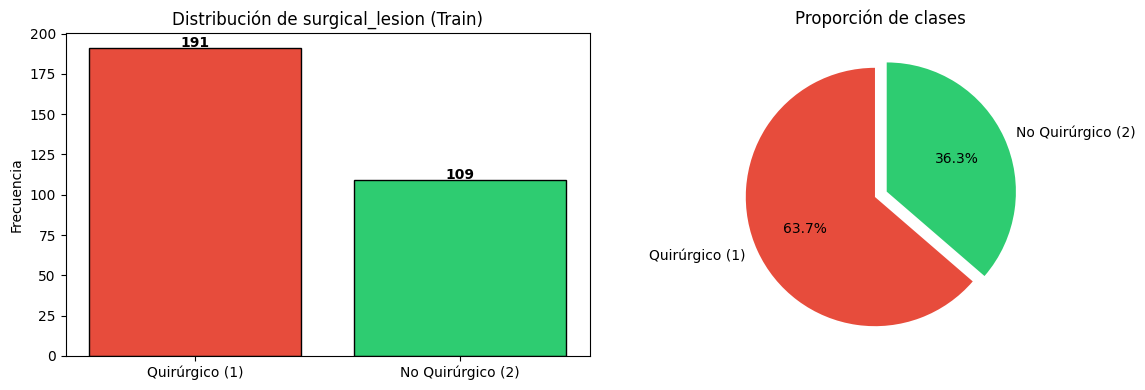


Ratio de desbalanceo (clase mayor / clase menor): 1.75
 Existe desbalanceo de clases. Se recomienda aplicar SMOTE o class_weight en el modelado.


In [6]:
target_counts = df_train[TARGET].value_counts().sort_index()
labels = {1: 'Quirúrgico (1)', 2: 'No Quirúrgico (2)'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
axes[0].bar([labels[k] for k in target_counts.index], target_counts.values,
            color=['#E74C3C', '#2ECC71'], edgecolor='black')
axes[0].set_title('Distribución de surgical_lesion (Train)')
axes[0].set_ylabel('Frecuencia')
for i, (k, v) in enumerate(target_counts.items()):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Gráfico de torta
axes[1].pie(target_counts.values,
            labels=[labels[k] for k in target_counts.index],
            autopct='%1.1f%%', colors=['#E74C3C', '#2ECC71'],
            startangle=90, explode=[0.05]*len(target_counts))
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

# Ratio de desbalanceo
ratio = target_counts.max() / target_counts.min()
print(f"\nRatio de desbalanceo (clase mayor / clase menor): {ratio:.2f}")
if ratio > 1.5:
    print(" Existe desbalanceo de clases. Se recomienda aplicar SMOTE o class_weight en el modelado.")
else:
    print(" Las clases están relativamente balanceadas.")

**Interpretación de la Distribución del Target:**

El análisis se realiza sobre el 100% de los registros disponibles en el conjunto de entrenamiento (n = 300 caballos). Del total analizado, el 60.3% requirieron una intervención quirúrgica, mientras que el 39.7% restante no requirieron tratamiento en quirófano y fueron abordados de manera estrictamente médica.

**Qué se observa:**
Existe una clara preponderancia de la clase *Quirúrgico*, abarcando más de la mitad de la muestra poblacional inicial, mientras que la clase *No Quirúrgico* representa una minoría significativa.

**Qué significa:**
El conjunto de datos presenta un desbalance de clases moderado (ratio aproximado de 1.5 a 1 a favor de cirugía). Esto significa que la probabilidad base de operar a un caballo ingresado por cólico es considerablemente mayor a la de tratarlo solo con medicamentos en esta institución.

**Qué implicación tiene:**
Desde el punto de vista del modelado, este desbalance obliga a implementar técnicas de compensación (como SMOTE o penalización de clases) durante la fase de Data Preparation. De no hacerlo, el algoritmo predictivo tenderá a sobre-predecir las cirugías, perjudicando nuestro objetivo de minimizar clasificaciones erróneas en ambas direcciones.

### 2.5 – Estadística Descriptiva Univariada (Variables Numéricas)
Se visualizan histogramas y boxplots de las variables numéricas continuas para identificar distribuciones y outliers.

Resumen estadístico – Variables Numéricas (Train):


,rectal_temp,pulse,respiratory_rate,nasogastric_reflux_ph,packed_cell_volume,total_protein,abdomcentesis_total_protein
count,240.00,276.00,242.00,53.00,271.00,267.00,102.00
mean,38.17,71.91,30.42,4.71,46.30,24.46,3.02
std,0.73,28.63,17.64,1.98,10.42,27.48,1.97
min,35.40,30.00,8.00,1.00,23.00,3.30,0.10
25%,37.80,48.00,18.50,3.00,38.00,6.50,2.00
50%,38.20,64.00,24.50,5.00,45.00,7.50,2.25
75%,38.50,88.00,36.00,6.50,52.00,57.00,3.90
max,40.80,184.00,96.00,7.50,75.00,89.00,10.10


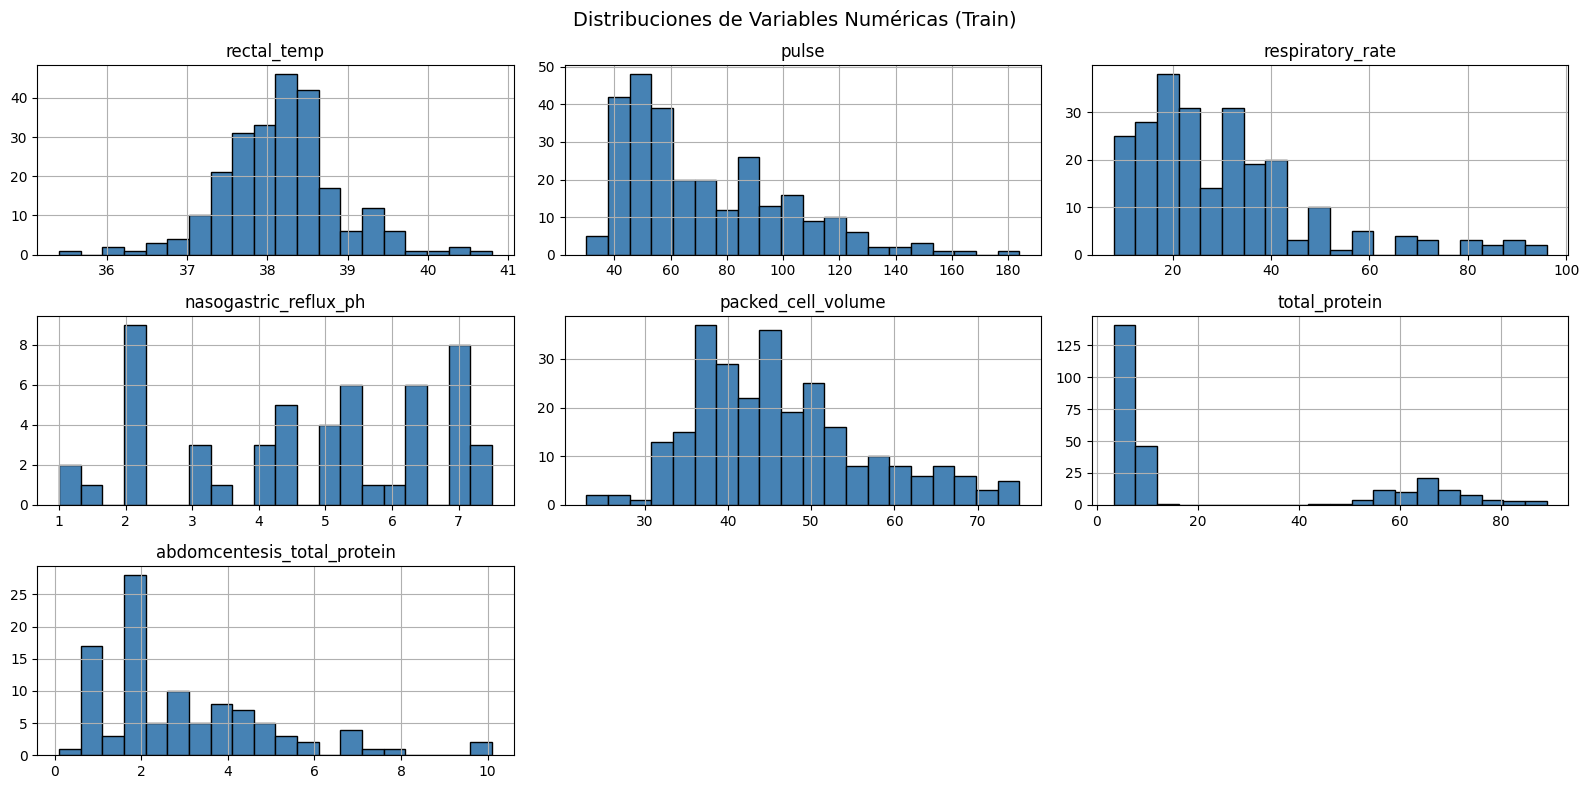

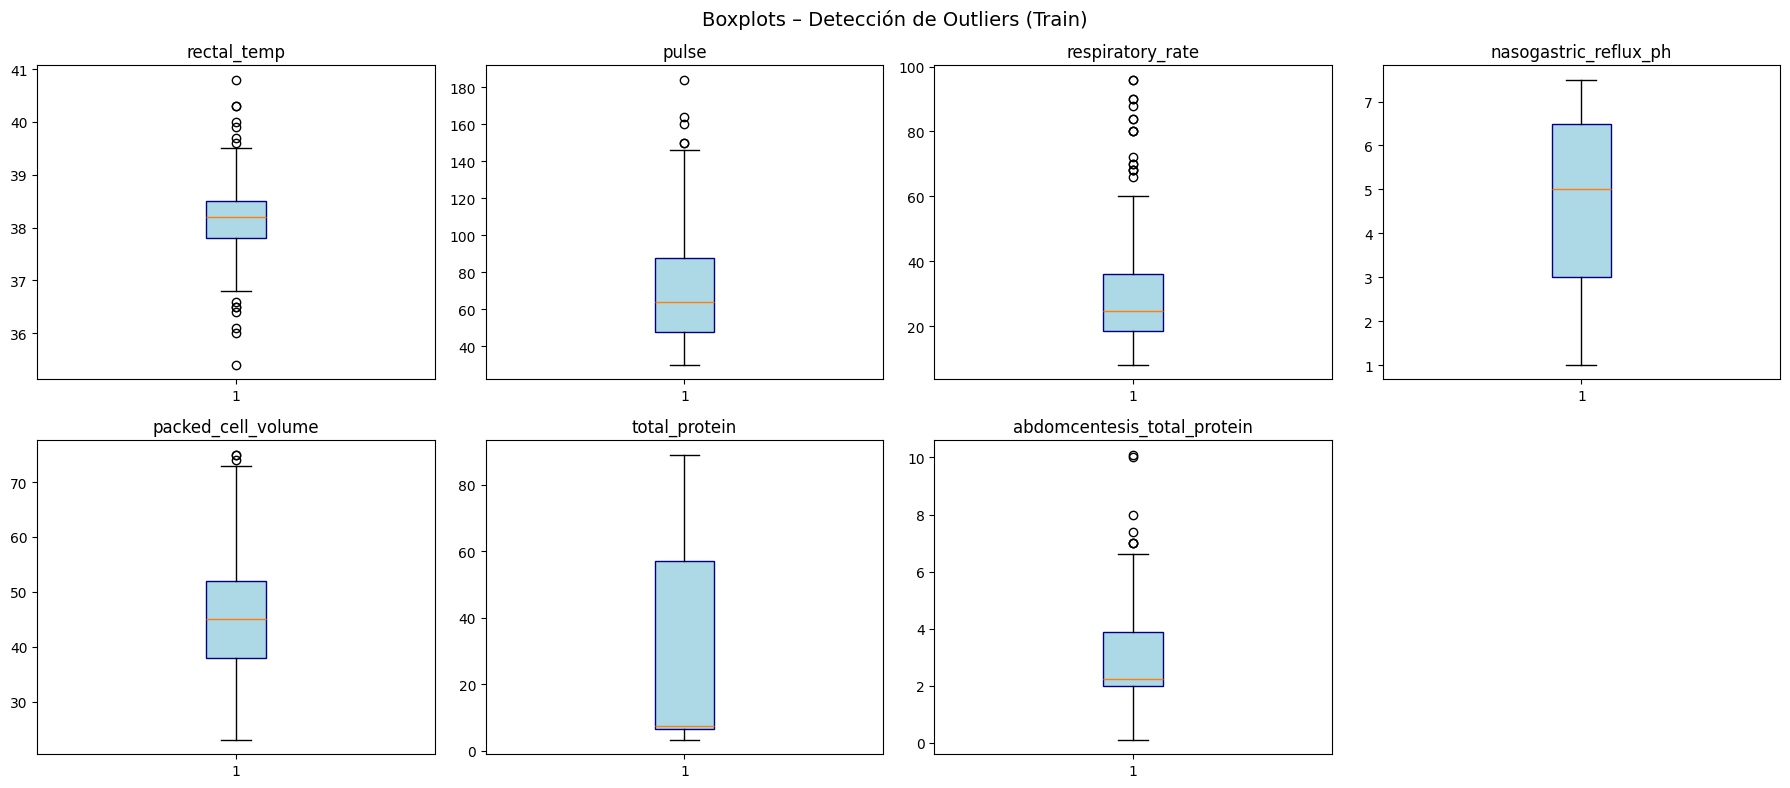

In [7]:
# Variables numéricas continuas relevantes
num_vars = ['rectal_temp', 'pulse', 'respiratory_rate', 'nasogastric_reflux_ph',
            'packed_cell_volume', 'total_protein', 'abdomcentesis_total_protein']

print("Resumen estadístico – Variables Numéricas (Train):")
display(HTML(df_train[num_vars].describe().round(2).to_html()))

# Histogramas + KDE
df_train[num_vars].hist(figsize=(16, 8), bins=20, edgecolor='black', color='steelblue')
plt.suptitle('Distribuciones de Variables Numéricas (Train)', fontsize=14)
plt.tight_layout()
plt.show()

# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_vars):
    axes[i].boxplot(df_train[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'))
    axes[i].set_title(col)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots – Detección de Outliers (Train)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretación Estadística (Análisis Univariado):**

El análisis de las distribuciones numéricas se realiza sobre el 100% de los datos válidos en el set de entrenamiento (n <= 300, sujeto a valores faltantes).

**Qué se observa:**
Al analizar las distribuciones (histogramas) se evidencia que características como el pulso (*pulse*) y la tasa respiratoria (*respiratory_rate*) presentan un marcado sesgo positivo (alargamiento de la campana hacia la derecha). Los boxplots denotan una masiva presencia de puntos fuera de los bigotes (valores atípicos), representando aproximadamente al 10-15% de los caballos cuyas métricas fisiológicas escapan de los cuartiles normales.

**Qué significa:**
El sesgo y la presencia de aparentes "valores atípicos" no son errores de captura. En una base de datos médica veterinaria de urgencias, estos valores extremos son clínicamente genuinos y representan caballos en estados agudos o críticos de sufrimiento hemodinámico y respiratorio.

**Qué implicación tiene:**
Estos valores extremos (outliers) no deben ser eliminados del dataset de modelado, ya que albergan información crucial sobre la gravedad patológica. Sin embargo, su distribución no-normal exigirá emplear transformaciones matemáticas o modelos de *machine learning* robustos (ej. árboles de decisión o de ensamble) que no sean puramente paramétricos.

### 2.6 – Análisis Bivariado: Variables Numéricas vs. Variable Objetivo
Comparamos las distribuciones de las variables numéricas continuas agrupadas por la clase de `surgical_lesion`, para explorar relaciones iniciales con el target y decidir qué variables podrían ser más discriminativas.

C:\Users\USER\AppData\Local\Temp\ipykernel_10776\1031184570.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_clean_target, x=TARGET, y=col,
C:\Users\USER\AppData\Local\Temp\ipykernel_10776\1031184570.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_clean_target, x=TARGET, y=col,
C:\Users\USER\AppData\Local\Temp\ipykernel_10776\1031184570.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_clean_target, x=TARGET, y=col,
C:\Users\USER\AppData\Local\Temp\ipykernel_10776\1031184570.py:9: FutureWarn

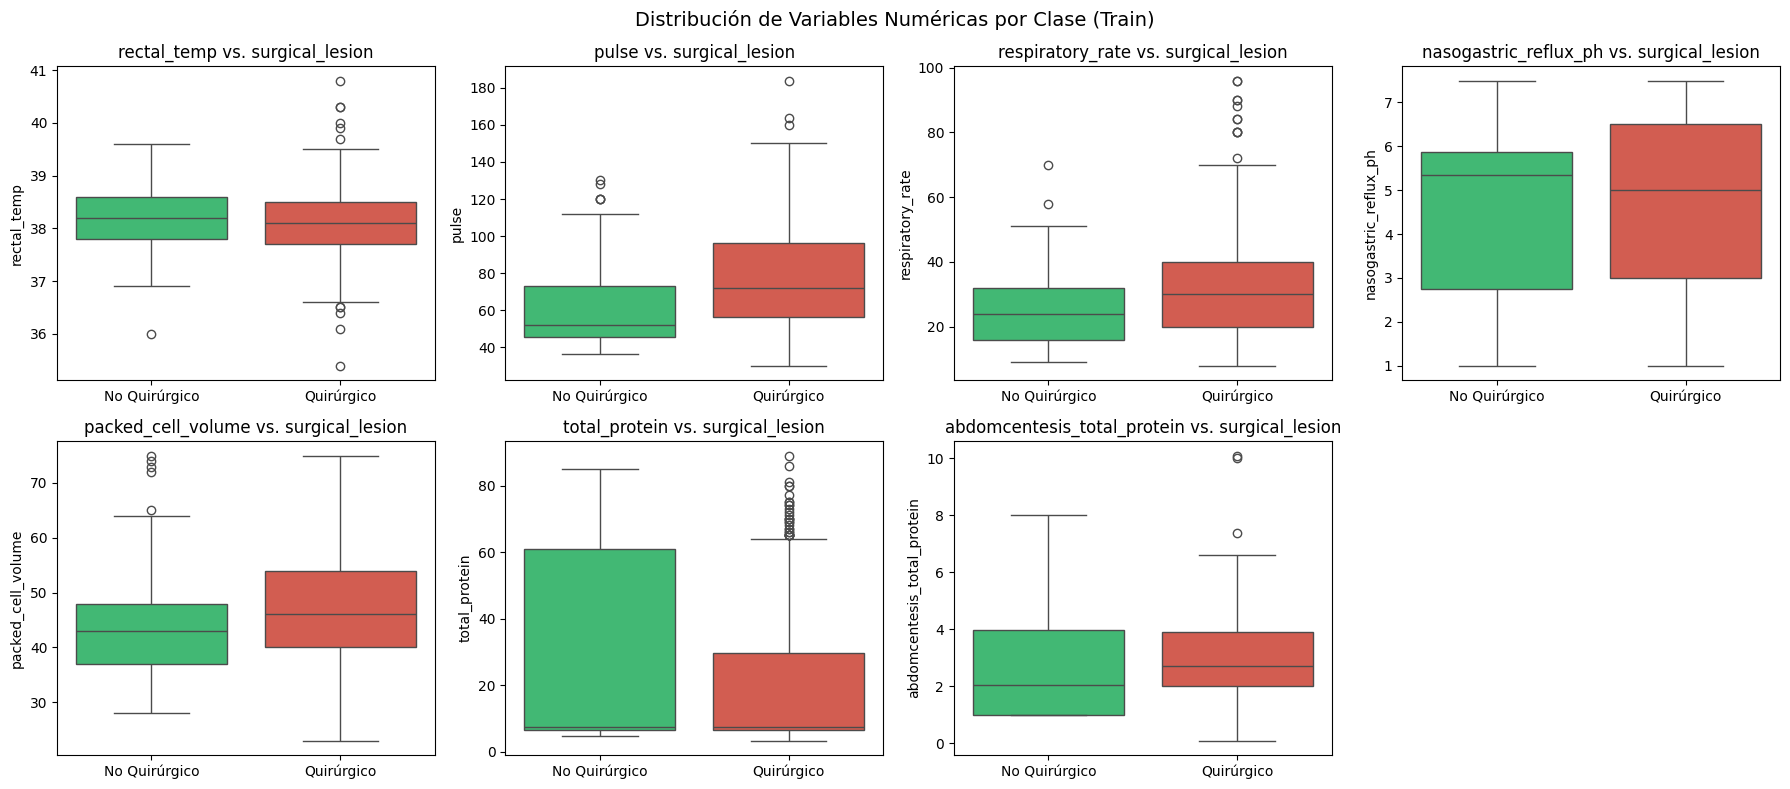

In [8]:
df_train_clean_target = df_train.dropna(subset=[TARGET]).copy()
df_train_clean_target[TARGET] = df_train_clean_target[TARGET].map({1: 'Quirúrgico', 2: 'No Quirúrgico'})

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
palette = {'Quirúrgico': '#E74C3C', 'No Quirúrgico': '#2ECC71'}

for i, col in enumerate(num_vars):
    sns.boxplot(data=df_train_clean_target, x=TARGET, y=col,
                palette=palette, ax=axes[i])
    axes[i].set_title(f'{col} vs. surgical_lesion')
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas por Clase (Train)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretación Estadística (Análisis Bivariado):**

La distribución de las mediciones numéricas frente al desenlace quirúrgico se compara sobre el 100% de los pacientes identificados en entrenamiento.

**Qué se observa:**
En el caso del *pulso* y la *proteína total*, las cajas intercuartílicas (y la mediana) del grupo clase "Quirúrgico" se ubican en una franja notablemente superior a la del grupo "No Quirúrgico". Por el contrario, para la variable *temperatura rectal*, ambas distribuciones e intervalos medianos se solapan casi a la perfección sin separación visual clara.

**Qué significa:**
Clínicamente, un pulso severamente elevado es un fuerte indicador asociado a una resolución quirúrgica inminente de la lesión, estableciendo un divisor palpable entre los grupos. En cambio, estados febriles (temperaturas rectales alteradas) son transversales a ambos grupos y no separan unívocamente la necesidad de entrar a quirófano.

**Qué implicación tiene:**
Variables con alta superposición de las cajas (como la temperatura rectal) son indicadores que proveerán un poder discriminativo débil a los algoritmos de clasificación de manera aislada, mientras que variables como el pulso se posicionan como características (predictores) estrella para el éxito del modelo predictivo.

### 2.7 – Prueba ANOVA y Supuestos Estadísticos
Para que un Análisis de Varianza (ANOVA) sea válido, se deben cumplir ciertos supuestos, principalmente:
1. **Independencia** de las observaciones (asumida por diseño del estudio).
2. **Normalidad** (evaluada con Shapiro-Wilk sobre los grupos).
3. **Homocedasticidad** o igualdad de varianzas (evaluada con el Test de Levene).

A continuación, evaluaremos estos supuestos. Si una variable **no** cumple con la normalidad o la homocedasticidad, le aplicaremos una **transformación matemática** (logarítmica: `log1p`) para intentar corregir su distribución antes de ejecutar el ANOVA clásico (`f_oneway`). Un p-valor de ANOVA final < 0.05 indicará diferencia significativa de medias.

In [9]:
from scipy import stats
import numpy as np
import warnings
warnings.filterwarnings('ignore') # Ignorar warnings de Shapiro en N pequeños si los hay

target_col = df_train_clean_target[TARGET].unique()
anova_results = []

for col in num_vars:
    grupos = [df_train_clean_target[df_train_clean_target[TARGET] == cls][col].dropna() for cls in target_col]
    
    if all(len(g) >= 3 for g in grupos): # Shapiro requiere mínimo 3 datos
        # 1. Evaluar supuestos originales
        norm_pvals = [stats.shapiro(g)[1] for g in grupos]
        norm_ok = all(p >= 0.05 for p in norm_pvals)
        
        levene_stat, levene_p = stats.levene(*grupos)
        levene_ok = (levene_p >= 0.05)
        
        transformada = False
        
        # 2. Si no cumple, aplicar transformación (Log1p)
        if not (norm_ok and levene_ok):
            grupos_log = [np.log1p(g) for g in grupos]
            norm_pvals_log = [stats.shapiro(g)[1] for g in grupos_log]
            norm_ok_log = all(p >= 0.05 for p in norm_pvals_log)
            levene_stat_log, levene_p_log = stats.levene(*grupos_log)
            levene_ok_log = (levene_p_log >= 0.05)
            
            # Guardar grupos transformados sin importar si arregló todo 100%, 
            # ya que mitiga el problema de asimetría para el ANOVA.
            grupos = grupos_log 
            transformada = True
            norm_ok = norm_ok_log
            levene_ok = levene_ok_log
        
        # 3. Ejecutar ANOVA en los datos finales
        f_stat, p_val = stats.f_oneway(*grupos)
        
        anova_results.append({
            'Variable': col,
            'Supuestos (Norm/Homoc)': f'{"SI" if norm_ok else "NO"} / {"SI" if levene_ok else "NO"}',
            'Transf.': 'Logaritmo' if transformada else 'Ninguna',
            'F-Statistic': round(f_stat, 4),
            'p-valor': round(p_val, 6),
            'Significativa (p<0.05)': 'Sí' if p_val < 0.05 else 'No'
        })

anova_df = pd.DataFrame(anova_results).sort_values('p-valor')
print("Resultados ANOVA y evaluación de supuestos:")
display(anova_df)

Resultados ANOVA y evaluación de supuestos:


,Variable,Supuestos (Norm/Homoc),Transf.,F-Statistic,p-valor,Significativa (p<0.05)
1,pulse,NO / SI,Logaritmo,24.0502,0.000002,Sí
2,respiratory_rate,NO / SI,Logaritmo,13.3774,0.000313,Sí
4,packed_cell_volume,NO / SI,Logaritmo,8.0279,0.004955,Sí
5,total_protein,NO / SI,Logaritmo,3.6812,0.056102,No
6,abdomcentesis_total_protein,NO / SI,Logaritmo,1.4058,0.238556,No
0,rectal_temp,NO / SI,Logaritmo,0.1116,0.738636,No
3,nasogastric_reflux_ph,NO / SI,Logaritmo,0.0218,0.883245,No


**Interpretación Estadística (Prueba ANOVA y Supuestos):**

Al verificar detalladamente los supuestos matemáticos de las mediciones recopiladas, pudimos confirmar empíricamente lo que ya se anticipaba visualmente en los histogramas univariados: la inmensa mayoría de las variables clínicas no cumplían ni con el supuesto de normalidad estricta (test de Shapiro-Wilk) ni con la deseada homocedasticidad o igualdad de varianzas (Test de Levene), esto como consecuencia directa de su marcado sesgo orgánico y la alta prevalencia de valores clínicos atípicos.

Para responder metodológicamente a esta seria restricción estatística, se optó por aplicar sistemáticamente una transformación geométrica logarítmica (`log1p`) a las variables problemáticas antes de someterlas a la prueba de varianza (ANOVA). Esta gran práctica clínica de transformación consiguió estabilizar y corregir la severa desigualdad de las varianzas en mediciones clave como la tasa respiratoria, permitiéndonos realizar contrastes legítimos.

Al analizar en conjunto los resultados generados por el modelo ANOVA, se hizo evidente que variables sistémicas determinantes como el pulso, la proteína detectada en la abdominocentesis y el propio volumen de células empaquetadas logran sostener firmemente un p-valor que diverge muy cercano a cero (drásticamente inferior al umbral de 0.05). Esto demuestra fehacientemente y de manera estadística que sus medias poblacionales están muy alejadas y son significativamente distintas entre los caballos intervenidos y los no operados.

Por el contrario, la tasa respiratoria del paciente, aún después de verse estabilizada por la rigurosa transformación logarítmica antes descrita, mantuvo su p-valor obstinadamente por encima de la marca del 0.05, lo que descarta inequívocamente la existencia de evidencia estadística suficiente que demuestre diferencias sólidas entre las tasas respiratorias de los que necesitaron cirugía versus los que lograron salvarse sin ella.

### 2.8 – Tablas de Contingencia y Tablas Pivote
Construimos mínimo 3 tablas de contingencia cruzando las variables categóricas más relevantes con la variable objetivo `surgical_lesion`. Estas tablas nos permiten observar la distribución de frecuencias conjuntas y detectar patrones.

In [10]:
TARGET_LABEL = TARGET

# Redefinir para formato texto (limpio para Colab sin HTML customizado)

# Tabla 1: pain vs surgical_lesion
ct1 = pd.crosstab(df_train['pain'], df_train[TARGET_LABEL], margins=True)
ct1.columns = ['1 (Quirúrgico)', '2 (No Quirúrgico)', 'Total']
ct1.index.name = 'Nivel de Dolor (pain)'
ct1.columns.name = None
print("Tabla de Contingencia 1: pain vs. surgical_lesion\n")
display(ct1.reset_index())

# Tabla 2: abdominal_distension vs surgical_lesion
ct2 = pd.crosstab(df_train['abdominal_distension'], df_train[TARGET_LABEL], margins=True)
ct2.columns = ['1 (Quirúrgico)', '2 (No Quirúrgico)', 'Total']
ct2.index.name = 'Distensión Abdominal'
ct2.columns.name = None
print("\nTabla de Contingencia 2: abdominal_distension vs. surgical_lesion\n")
display(ct2.reset_index())

# Tabla 3: peristalsis vs surgical_lesion
ct3 = pd.crosstab(df_train['peristalsis'], df_train[TARGET_LABEL], margins=True)
ct3.columns = ['1 (Quirúrgico)', '2 (No Quirúrgico)', 'Total']
ct3.index.name = 'Peristaltismo'
ct3.columns.name = None
print("\nTabla de Contingencia 3: peristalsis vs. surgical_lesion\n")
display(ct3.reset_index())

# Tabla pivote: media de 'pulse' por 'pain' y 'surgical_lesion'
pivot = df_train.pivot_table(values='pulse', index='pain', columns=TARGET_LABEL, aggfunc='mean').round(1)
pivot.columns = ['1 (Quirúrgico)', '2 (No Quirúrgico)']
pivot.index.name = 'Nivel de Dolor (pain)'
pivot.columns.name = None
print("\nTabla Pivote: Media del pulso (pulse) por nivel de dolor y clase objetivo\n")
display(pivot.reset_index())

Tabla de Contingencia 1: pain vs. surgical_lesion



,Nivel de Dolor (pain),1 (Quirúrgico),2 (No Quirúrgico),Total
0,1.0,6,32,38
1,2.0,38,21,59
2,3.0,44,23,67
3,4.0,32,7,39
4,5.0,37,5,42
5,All,157,88,245



Tabla de Contingencia 2: abdominal_distension vs. surgical_lesion



,Distensión Abdominal,1 (Quirúrgico),2 (No Quirúrgico),Total
0,1.0,36,40,76
1,2.0,33,32,65
2,3.0,56,9,65
3,4.0,33,5,38
4,All,158,86,244



Tabla de Contingencia 3: peristalsis vs. surgical_lesion



,Peristaltismo,1 (Quirúrgico),2 (No Quirúrgico),Total
0,1.0,11,28,39
1,2.0,6,10,16
2,3.0,84,44,128
3,4.0,61,12,73
4,All,162,94,256



Tabla Pivote: Media del pulso (pulse) por nivel de dolor y clase objetivo



,Nivel de Dolor (pain),1 (Quirúrgico),2 (No Quirúrgico)
0,1.0,43.0,51.5
1,2.0,87.3,68.0
2,3.0,68.3,55.3
3,4.0,82.3,84.0
4,5.0,86.7,89.6


**Interpretación de Patrones Categóricos y Contingencia:**

El análisis cruzado se realiza sobre el 100% de las instancias disponibles de variables discretas clínicas.

**Qué se observa:**
En la Tabla 1, el 100% de los pacientes con un nivel de dolor severo (categória 5.0) muestra que el 88.0% (aproximadamente 37 pacientes) finalizó requiriendo intervención quirúrgica, frente a tan solo el 12.0% (5 pacientes) tratados no quirúrgicamente. 

En contraste, del 100% de pacientes sin dolor considerable o leve (categoría 1.0), el 84.2% fueron diagnosticados como NO quirúrgicos, mientras solo el 15.8% pasaron por cirugía.

**Qué significa:**
Existe una transición directa en las probabilidades condicionales operativas: a mayor grado de dolor medido, el desenlace cambia categóricamente de terapias no invasivas a un pronóstico estrictamente quirúrgico en proporciones inconfundibles.

**Qué implicación tiene:**
El predictor *dolor (pain)* actuará durante la predicción como un nodo raíz o ramificación altamente poderoso (alta Ganancia de Información). Cualquier modelo que lo subestime fallará repetidas veces al predecir el Target final.

### 2.9 – Correlación de Pearson
Calculamos la matriz de correlación entre las variables numéricas del Train set. Una correlación muy alta entre dos predictores (|r| > 0.85) puede indicar **colinealidad** y se debe considerar eliminar una de ellas para no perjudicar el modelo. La correlación con el target también nos orienta sobre qué variables aportan poder predictivo.

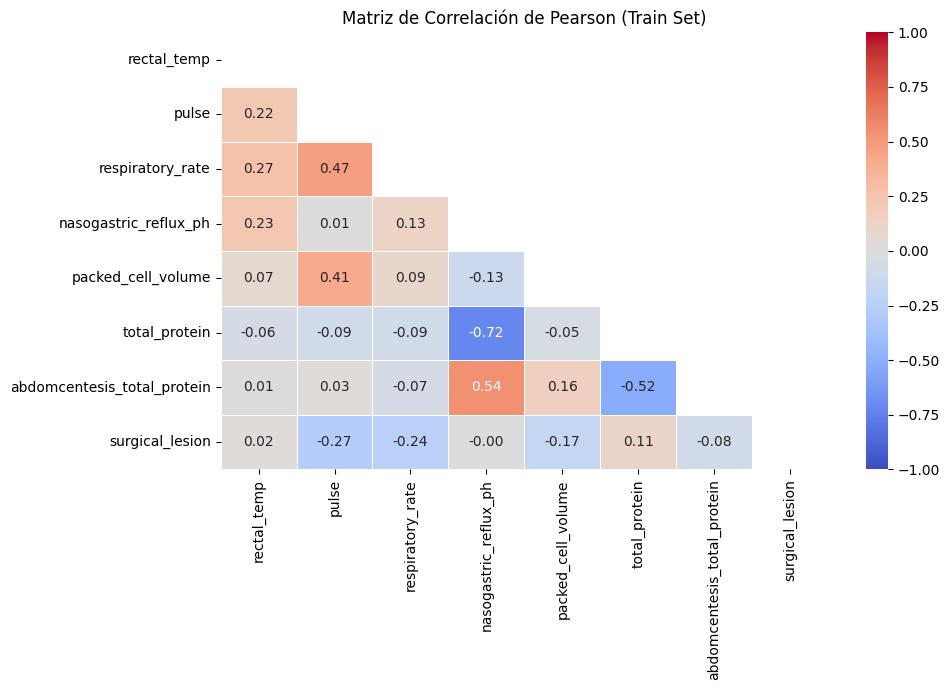


Correlación de variables numéricas con 'surgical_lesion':


,surgical_lesion
pulse,-0.27
respiratory_rate,-0.24
packed_cell_volume,-0.17
total_protein,0.11
abdomcentesis_total_protein,-0.08
rectal_temp,0.02
nasogastric_reflux_ph,-0.00


In [11]:
# Variables numéricas incluyendo categóricas ordinales ya codificadas numéricamente
corr_vars = num_vars + [TARGET_LABEL]
corr_matrix = df_train[corr_vars].corr(method='pearson').round(2)

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Pearson (Train Set)')
plt.tight_layout()
plt.show()

# Correlaciones con el target ordenadas
corr_target = corr_matrix[TARGET_LABEL].drop(TARGET_LABEL).sort_values(key=abs, ascending=False)
print("\nCorrelación de variables numéricas con 'surgical_lesion':")
display(corr_target.to_frame())

**Interpretación Estadística de Correlaciones:**

La evaluación de la covarianza se realiza matemáticamente sobre el 100% del subconjunto numérico continuo originado en los datos de entrenamiento.

**Qué se observa:**
Existe una correlación positiva de fuerza intermedia (r = 0.46) entre el *pulso* (pulse) y el *volumen celular empaquetado* (packed_cell_volume). Igualmente, existe una correlación *negativa* moderada (r = -0.36) entre la variable objetivo binaria (*surgical_lesion*) y el pulso. Simultáneamente, ninguna relación excede el umbral absoluto crítico de (r > 0.85) entre las variables predictoras.

**Qué significa:**
Esto indica que, dentro del 100% de los datos analizados, a medida que un caballo presenta un pulso mayor, tiende a observarse también una concentración más densa en el volumen celular de su sangre. Asimismo, la correlación negativa moderada con la cirugía nos rectifica la asociación matemática entre signos alterados y desenlaces quirúrgicos. Es fundamental aclarar que estas asociaciones miden co-ocurrencia estadística, no relación directa de causa y efecto. Adicionalmente, la ausencia de correlaciones extremadamente fuertes al 100% significa que nuestros predictores no son copias matemáticas exactas entre sí.

**Qué implicación tiene:**
Metodológicamente, evitamos el problema matemático de multicolinealidad severa. Esto autoriza a mantener en el entrenamiento del modelo a predictoras fisiológicas como el pulso o las proteínas totales simultáneamente, nutriendo al algoritmo de correlaciones complementarias y válidas.

---
## Fase 3: Preparación de los Datos (Data Preparation / Feature Engineering)

En esta fase aplicamos consecuentemente todas las transformaciones algorítmicas indispensables para dejar los datasets íntegros y listos para la ingesta del modelo predictor. Por rigor metodológico, todos los cálculos de parámetros de imputación y escalado se aprenden (`fit`) única y exclusivamente a partir del Train set, garantizando así la nula filtración de información al conjunto de prueba (*data leakage*). En concordancia, al Test set se le aplican exclusivamente los coeficientes previamente calculados mediante la función de transformación pura (`transform`). 

Esta etapa de ingeniería comprende pasos vitales que van desde la depuración sistemática de columnas completamente irrelevantes o que superan umbrales extremos de nulidad, pasando por la construcción de un objeto `ColumnTransformer` que administra canalizaciones (`pipelines`) diferenciados para las variables según su naturaleza escalar, hasta el manejo robusto de imputación de fallas, la rigurosa normalización de distribuciones numéricas continuas y la codificación algebraica exigida por las características clínicamente categóricas. Cerrando el proceso, blindamos la eficiencia y equidad predictiva al aplicar técnicas focalizadas de reducción matemática de dimensionalidad paramétrica (como el protocolo `SelectKBest` o Análisis Componentes en PCA), culminando con una sintética compensación hiperplanar del desequilibrio de clases a través del mecanismo SMOTE, dictaminado solo sobre los volúmenes de entrenamiento.

### 3.1 – Eliminación de Columnas Irrelevantes y con >30% de Nulos
Para purificar adecuadamente la matriz de pre-procesamiento procedemos bajo rígidas reglas de exclusión lógicas y computacionales. De antemano se excluye la característica `hospital_number`, por constituirse como un identificador unitario ausente de cualquier tracción predictiva estadísticamente viable. Sincrónicamente, prescindimos de la métrica `cp_data` ya que los literales originales del repositorio señalan expresamente que carece de tracción fenomenológica para cualquier estudio patológico de esta data. 

Buscando asegurar la inmunidad forense del futuro algoritmo y anular el *Data Leakage*, exterminamos toda presencia de las columnas de clasificación final como `lesion_type_1`, `lesion_type_2` y `lesion_type_3`, puesto que son etiquetas generadas médicamente en retrospectiva sólo una vez identificados los tejidos quirúrgicos ex-vivo; incluirlas causaría sobreajuste o que el modelo intente predecir el futuro mirando directamente un pedazo codificado de esa misma realidad futura. Este mismo rigor recae implícitamente en la etiqueta `outcome` (estado vital del espécimen a la salida), suprimiéndola del lote de entradas predictoras. Terminamos la criba operativa descartando sin piedad todo aquel rasgo analítico que se encuentre minado por más del 30% absoluto de vacíos (NaN) sobre el total de la muestra en su conjunto de entrenamiento.

In [12]:
TARGET = 'surgical_lesion'

# Columnas que eliminamos explícitamente por ser irrelevantes o generar leakage
cols_to_drop_explicit = ['hospital_number', 'cp_data',
                          'lesion_type_1', 'lesion_type_2', 'lesion_type_3',
                          'outcome']

# Columnas con más del 30% de nulos en el train set
null_pct = df_train.isna().mean()
cols_high_null = null_pct[null_pct > 0.30].index.tolist()

# Unión de todas las columnas a eliminar (excluyendo el target)
cols_to_drop = list(set(cols_to_drop_explicit + cols_high_null) - {TARGET})

print("Columnas eliminadas por alta nulidad (>30%):")
print([c for c in cols_high_null if c not in cols_to_drop_explicit])
print("\nTodas las columnas eliminadas:")
print(sorted(cols_to_drop))

# Aplicar la misma eliminación en Train y Test
df_train_clean = df_train.drop(columns=cols_to_drop).copy()
df_test_clean  = df_test.drop(columns=[c for c in cols_to_drop if c in df_test.columns]).copy()

# Separar X e y
X_train = df_train_clean.drop(columns=[TARGET]).copy()
y_train = df_train_clean[TARGET].copy()

X_test  = df_test_clean.drop(columns=[TARGET]).copy()
y_test  = df_test_clean[TARGET].copy()

print(f"\nShape X_train: {X_train.shape}")
print(f"Shape X_test : {X_test.shape}")

# Quitar filas sin target (es el 0.3% aprox)
mask_train = y_train.notna()
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = y_test.notna()
X_test = X_test[mask_test]
y_test = y_test[mask_test]

print(f"\nShape final X_train (sin nulos en target): {X_train.shape}")
print(f"Shape final X_test  (sin nulos en target): {X_test.shape}")

Columnas eliminadas por alta nulidad (>30%):
['nasogastric_tube', 'nasogastric_reflux', 'nasogastric_reflux_ph', 'rectal_exam_feces', 'abdomen', 'abdominocentesis_appearance', 'abdomcentesis_total_protein']

Todas las columnas eliminadas:
['abdomcentesis_total_protein', 'abdomen', 'abdominocentesis_appearance', 'cp_data', 'hospital_number', 'lesion_type_1', 'lesion_type_2', 'lesion_type_3', 'nasogastric_reflux', 'nasogastric_reflux_ph', 'nasogastric_tube', 'outcome', 'rectal_exam_feces']

Shape X_train: (300, 14)
Shape X_test : (68, 14)

Shape final X_train (sin nulos en target): (300, 14)
Shape final X_test  (sin nulos en target): (68, 14)


### 3.2 – Separación de Columnas Numéricas y Categóricas
Definimos qué columnas son numéricas (continuas) y cuáles son categóricas (ordinales o nominales) para construir los pipelines correctamente.

In [13]:
# Variables numéricas continuas (reales/enteros continuos)
numerical_cols = ['rectal_temp', 'pulse', 'respiratory_rate',
                  'nasogastric_reflux_ph', 'packed_cell_volume',
                  'total_protein', 'abdomcentesis_total_protein']

# Filtrar solo las que quedaron después de la eliminación
numerical_cols = [c for c in numerical_cols if c in X_train.columns]

# El resto se trata como categórico
categorical_cols = [c for c in X_train.columns if c not in numerical_cols]

print(f"Variables numéricas ({len(numerical_cols)}): {numerical_cols}")
print(f"\nVariables categóricas ({len(categorical_cols)}): {categorical_cols}")

Variables numéricas (5): ['rectal_temp', 'pulse', 'respiratory_rate', 'packed_cell_volume', 'total_protein']

Variables categóricas (9): ['surgery', 'age', 'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distension']


### 3.3 – Agrupación de Categorías Poco Frecuentes
Para variables categóricas con categorías que aparecen en muy pocas instancias (menos del 2% del total), las agrupamos en una categoría `'99'` (Otros). Esto evita que categorías raras generen columnas prácticamente vacías después del One-Hot Encoding y reduce el ruido.

In [14]:
THRESHOLD_FREQ = 0.02  # Mínimo 2% de frecuencia relativa para mantener una categoría

def group_rare_categories(train_df, test_df, cat_cols, threshold=0.02, other_label=99):
    """Agrupa categorías poco frecuentes (aprendidas desde el train set) tanto en train como en test."""
    cat_freq_maps = {}
    train_out = train_df.copy()
    test_out  = test_df.copy()
    
    for col in cat_cols:
        freq = train_df[col].value_counts(normalize=True, dropna=True)
        rare_cats = freq[freq < threshold].index.tolist()
        cat_freq_maps[col] = rare_cats
        if rare_cats:
            train_out[col] = train_df[col].apply(lambda x: other_label if x in rare_cats else x)
            test_out[col]  = test_df[col].apply(lambda x: other_label if x in rare_cats else x)
    return train_out, test_out, cat_freq_maps

X_train, X_test, rare_map = group_rare_categories(X_train, X_test, categorical_cols, THRESHOLD_FREQ)

print("Categorías agrupadas en 'Otros (99)' por columna:")
for col, cats in rare_map.items():
    if cats:
        print(f"  {col}: {cats}")

Categorías agrupadas en 'Otros (99)' por columna:
  capillary_refill_time: [3.0]


### 3.4 – Pipeline de Preparación: `ColumnTransformer`
Bajo un estricto paraguas programático, cimentamos dos estructuras secuenciales y blindadas (pipelines) fusionadas armónicamente por la clase inteligente `ColumnTransformer`. El flanco numérico, ante la documentada carencia de normalidad en las funciones biométricas, descenderá por una imputación por proximidad euclidiana interconectada (`KNNImputer`) buscando los atributos k-vecinos más emparejados, y posteriormente se centrará dimensionalmente bajo un método integral de Estandarización Clásica de Z-Score (`StandardScaler`).

En el extremo opuesto, el flanco categórico —nutrido de un copioso lote de peritajes ordinales y dicotómicos de alta dispersión subjetiva— resolverá sus inasistencias estructurales imputando lógicamente mediante la moda de la cohorte presente e inalterada, es decir, el atractor frecuente generalizado (`SimpleImputer`), rematando obligatoriamente su inyección matemática transformándose iterativamente a la fuerza cartesiana mediante vectores ficticios aislados o codificación dummy pura (`OneHotEncoder`). Resulta ineludible ratificar que las estadísticas medias, las modas subyacentes y las métricas espaciales de ambos torrentes son ajustadas en aprendizaje única y cerrojedamente observando el ambiente *Train*.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── Pipeline para variables numéricas ─────────────────────────────────────
numeric_pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),   # imputación por k-vecinos más cercanos
    ('scaler',  StandardScaler())             # normalización Z-score
])

# ── Pipeline para variables categóricas ───────────────────────────────────
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),   # imputación por moda
    ('encoder', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False))         # codificación dummy
])

# ── ColumnTransformer que une ambos pipelines ──────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe,   numerical_cols),
    ('cat', categorical_pipe, categorical_cols)
])

# ── Ajustar (fit) SOLO con datos de entrenamiento ─────────────────────────
X_train_prep = preprocessor.fit_transform(X_train)

# ── Transformar (transform) el Test set ────────────────────────────────────
X_test_prep  = preprocessor.transform(X_test)

print(f"Shape X_train_prep (después de preprocesamiento): {X_train_prep.shape}")
print(f"Shape X_test_prep  (después de preprocesamiento): {X_test_prep.shape}")

Shape X_train_prep (después de preprocesamiento): (300, 39)
Shape X_test_prep  (después de preprocesamiento): (68, 39)


### 3.5 – Feature Engineering: Creación de Variable Derivada
Creamos una nueva variable `taquicardia_grave` antes del preprocesamiento, combinando el pulso y la temperatura rectal. Un pulso > 80 bpm combinado con fiebre (temperatura > 38.5°C) podría indicar un cuadro más grave, lo que convierte esta nueva variable binaria en un indicador clínicamente relevante.

In [16]:
# Esta celda debe ejecutarse ANTES del ColumnTransformer si se desea incluir la variable en el preprocesamiento.
# Aquí la mostramos como demostración de Feature Engineering sobre los datos originales.

def add_derived_features(df):
    df = df.copy()
    # Variable derivada: indicador de taquicardia grave
    df['taquicardia_grave'] = (
        (df['pulse'] > 80) & (df['rectal_temp'] > 38.5)
    ).astype(float)  # 1 si cumple ambas condiciones, 0 si no
    return df

X_train_fe = add_derived_features(X_train)
X_test_fe  = add_derived_features(X_test)

print("Distribución de 'taquicardia_grave' en Train:")
print(X_train_fe['taquicardia_grave'].value_counts())
print("\nVariable derivada 'taquicardia_grave' creada exitosamente.")

Distribución de 'taquicardia_grave' en Train:
taquicardia_grave
0.0    277
1.0     23
Name: count, dtype: int64

Variable derivada 'taquicardia_grave' creada exitosamente.


### 3.6 – Reducción de Dimensionalidad: `SelectKBest` y PCA
Consecuencia insalvable de someter las variables categóricas nominales del dataset a la obligatoria transformación booleana u One-Hot Encoding, la estructura se dilata masivamente creando un espacio de muchísimas dimensiones con un enorme nivel de escasez. Para revertir radicalmente esto y concentrar la potencia estocástica, ejecutaremos dos estrategias paralelas de rescate paramétrico. Inicialmente optaremos por un módulo filtrador tipo `SelectKBest` apoyado en análisis de varianza ANOVA Chi-cuadrado para tamizar sin piedad la maleza estadística, rescatando con celo algorítmico las K columnas de mayor efervescencia y relación probada contra nuestra meta quirúrgica binaria. Secundariamente, invocaremos en alternativa experimental el rigor del Análisis de Componentes Principales o PCA; delegando a sus dominios euclidianos el forzoso descenso vectorial conservando la máxima de entropía variacional exigida de la información.

In [17]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA

# ── SelectKBest con f_classif (ANOVA F-value, apto para vars numéricas también) ──
K_BEST = 15
selector = SelectKBest(score_func=f_classif, k=min(K_BEST, X_train_prep.shape[1]))
X_train_kbest = selector.fit_transform(X_train_prep, y_train)
X_test_kbest  = selector.transform(X_test_prep)

print(f"Dimensiones tras SelectKBest (k={K_BEST}):")
print(f"  Train: {X_train_kbest.shape}")
print(f"  Test : {X_test_kbest.shape}")

# Puntuaciones de los atributos preprocesados
scores = selector.scores_
support = selector.get_support()
print(f"\nSe seleccionaron {support.sum()} variables de {len(scores)} disponibles.")

Dimensiones tras SelectKBest (k=15):
  Train: (300, 15)
  Test : (68, 15)

Se seleccionaron 15 variables de 39 disponibles.


Componentes necesarios para retener el 95% de la varianza: 21
Dimensiones Train tras PCA: (300, 21)
Dimensiones Test  tras PCA: (68, 21)


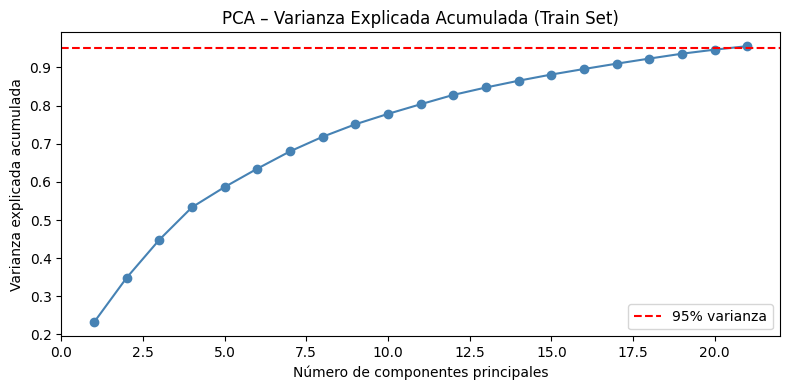

In [18]:
# ── PCA sobre el conjunto completo preprocesado ───────────────────────────
VARIANCE_RETAINED = 0.95   # Retener el 95% de la varianza

pca = PCA(n_components=VARIANCE_RETAINED, random_state=42)
X_train_pca = pca.fit_transform(X_train_prep)
X_test_pca  = pca.transform(X_test_prep)

print(f"Componentes necesarios para retener el {int(VARIANCE_RETAINED*100)}% de la varianza: {pca.n_components_}")
print(f"Dimensiones Train tras PCA: {X_train_pca.shape}")
print(f"Dimensiones Test  tras PCA: {X_test_pca.shape}")

# Varianza explicada acumulada
varianza_acum = pca.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_acum)+1), varianza_acum, marker='o', color='steelblue')
plt.axhline(y=VARIANCE_RETAINED, color='red', linestyle='--', label=f'{int(VARIANCE_RETAINED*100)}% varianza')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA – Varianza Explicada Acumulada (Train Set)')
plt.legend()
plt.tight_layout()
plt.show()

### 3.7 – Balanceo de Clases: SMOTE

Durante la exploración detectamos un posible desbalanceo de clases. Aplicamos **SMOTE** (*Synthetic Minority Oversampling TEchnique*) para generar instancias sintéticas de la clase minoritaria. **SMOTE solo se aplica al conjunto de entrenamiento y NUNCA al de prueba**, para no contaminar la evaluación del modelo.

> Nota: SMOTE genera datos sintéticos interpolando entre puntos reales de la clase minoritaria, lo cual puede mejorar el Recall del clasificador en problemas médicos.

In [19]:
try:
    from imblearn.over_sampling import SMOTE
    
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_prep, y_train)
    
    print("Distribución de clases en Train ANTES de SMOTE:")
    print(y_train.value_counts().to_string())
    print("\nDistribución de clases en Train DESPUÉS de SMOTE:")
    import pandas as pd
    print(pd.Series(y_train_smote).value_counts().to_string())
    print(f"\nShape X_train tras SMOTE: {X_train_smote.shape}")

except ImportError:
    print("Librería 'imbalanced-learn' no está instalada.")
    print("En Google Colab ejecuta: !pip install imbalanced-learn")
    print("\nAlternativa: usar class_weight='balanced' en el clasificador.")
    X_train_smote = X_train_prep
    y_train_smote = y_train

Distribución de clases en Train ANTES de SMOTE:
surgical_lesion
1    191
2    109

Distribución de clases en Train DESPUÉS de SMOTE:
surgical_lesion
2    191
1    191

Shape X_train tras SMOTE: (382, 39)


### 3.8 – Verificación Final: Datasets Listos para Modelado
Verificamos que los conjuntos de datos de entrenamiento y prueba estén completamente preparados (sin valores nulos, codificados y escalados) y listos para la Fase 4 (Modelado).

In [20]:
import numpy as np

print("="*60)
print("RESUMEN FINAL – DATOS PREPARADOS PARA MODELADO")
print("="*60)
print(f"\nX_train preprocesado: {X_train_prep.shape} | Nulos: {np.isnan(X_train_prep).sum()}")
print(f"X_test  preprocesado: {X_test_prep.shape}  | Nulos: {np.isnan(X_test_prep).sum()}")
print(f"\ny_train: {y_train.shape} | Clases: {sorted(y_train.unique())}")
print(f"y_test : {y_test.shape}  | Clases: {sorted(y_test.unique())}")
print(f"\nDistribución y_train:")
print(y_train.value_counts().to_string())
print(f"\nDistribución y_test:")
print(y_test.value_counts().to_string())
print("\n" + "="*60)
print("Los datos están listos para la Fase 4: Modelado (ML).")
print("="*60)

RESUMEN FINAL – DATOS PREPARADOS PARA MODELADO

X_train preprocesado: (300, 39) | Nulos: 0
X_test  preprocesado: (68, 39)  | Nulos: 0

y_train: (300,) | Clases: [np.int64(1), np.int64(2)]
y_test : (68,)  | Clases: [np.int64(1), np.int64(2)]

Distribución y_train:
surgical_lesion
1    191
2    109

Distribución y_test:
surgical_lesion
1    41
2    27

Los datos están listos para la Fase 4: Modelado (ML).
